# Projet 8 — Classification de la qualité du poisson
## Fish Market Dataset

**Objectif :** Prédire l'espèce d'un poisson à partir de ses caractéristiques physiques (poids, longueurs, hauteur, largeur).

---
**Dataset :** Fish Market (160 observations, 7 colonnes)  
**Tâche :** Classification multi-classes  
**Algorithmes testés :** k-NN, Arbre de décision, Random Forest, SVM


##  Installation et imports

In [1]:
# Installation des bibliothèques nécessaires
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [2]:
# Imports principaux
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# Sklearn - modèles
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Sklearn - métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Sauvegarde du modèle
import joblib

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print(' Imports OK')

 Imports OK


##  1. Chargement des données

In [3]:
# Chargement du dataset


df = pd.read_csv('Fish.csv')

print(f'Dimensions du dataset : {df.shape}')
print(f'\nNombre de lignes : {df.shape[0]}')
print(f'Nombre de colonnes : {df.shape[1]}')
df.head(10)

Dimensions du dataset : (159, 7)

Nombre de lignes : 159
Nombre de colonnes : 7


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
5,Bream,450.0,26.8,29.7,34.7,13.6024,4.9274
6,Bream,500.0,26.8,29.7,34.5,14.1795,5.2785
7,Bream,390.0,27.6,30.0,35.0,12.6700,4.6900
8,Bream,450.0,27.6,30.0,35.1,14.0049,4.8438
9,Bream,500.0,28.5,30.7,36.2,14.2266,4.9594


##  2. Exploration des données (EDA)

In [4]:
# Informations générales
print('=== Informations générales ===')
df.info()

print('\n=== Statistiques descriptives ===')
df.describe()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB

=== Statistiques descriptives ===


,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [5]:
# Vérification des valeurs manquantes
print('=== Valeurs manquantes ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal valeurs manquantes : {missing.sum()}')

=== Valeurs manquantes ===
Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

Total valeurs manquantes : 0


=== Distribution des espèces ===
Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


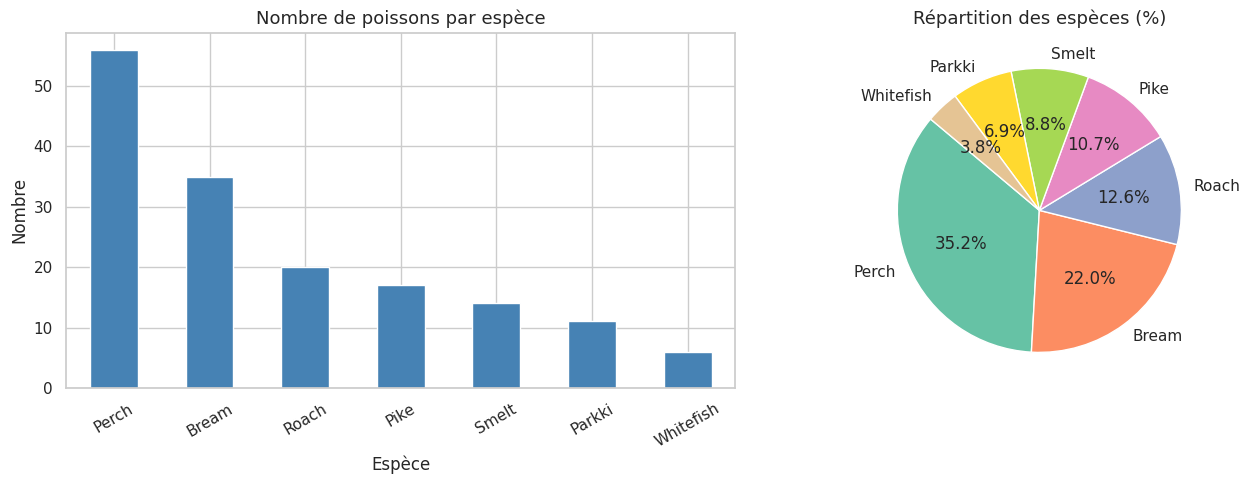

In [6]:
# Distribution des espèces
print('=== Distribution des espèces ===')
species_count = df['Species'].value_counts()
print(species_count)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
species_count.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Nombre de poissons par espèce', fontsize=13)
axes[0].set_xlabel('Espèce')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(species_count, labels=species_count.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', len(species_count)))
axes[1].set_title('Répartition des espèces (%)', fontsize=13)

plt.tight_layout()
plt.savefig('distribution_especes.png', bbox_inches='tight')
plt.show()

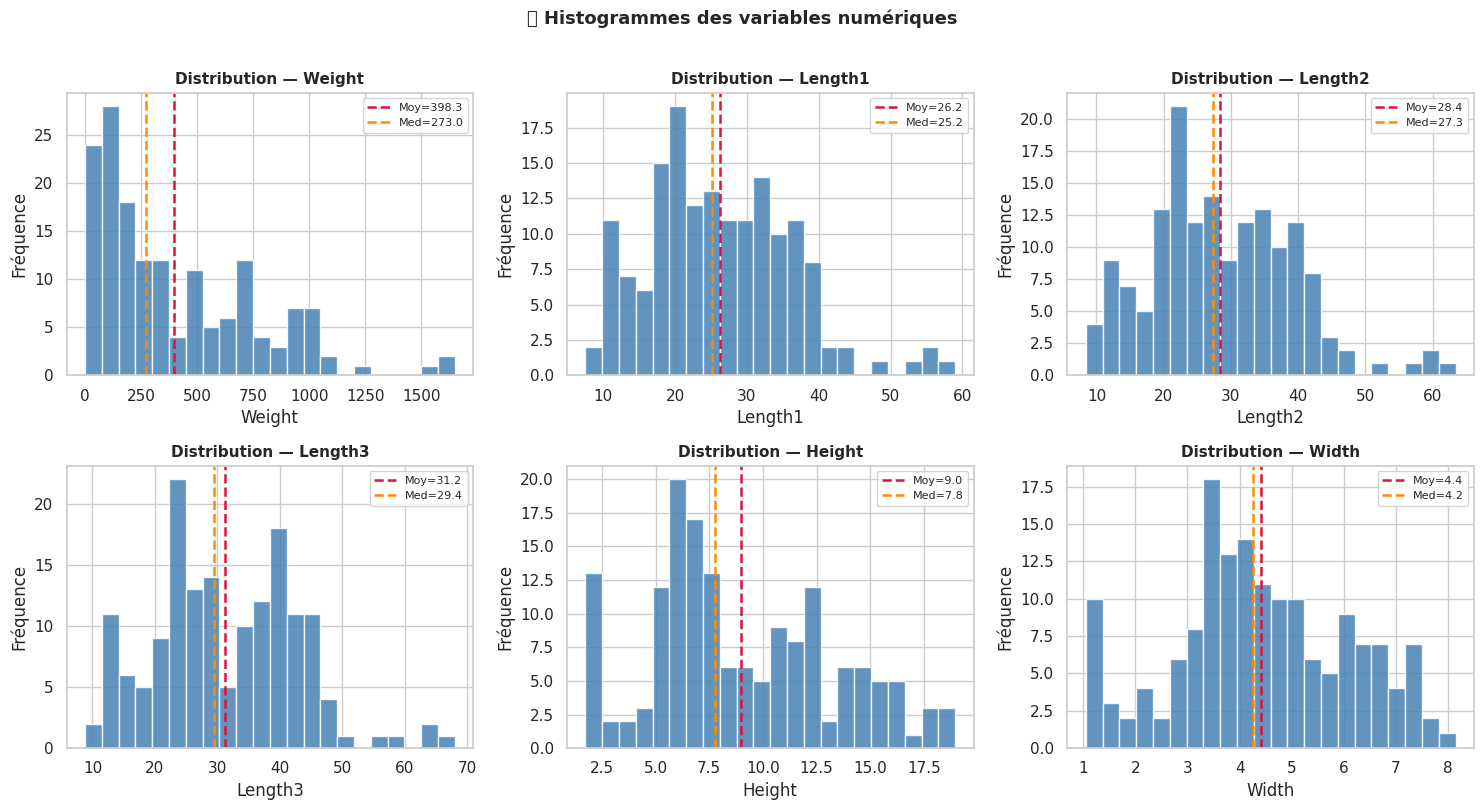

💡 Observation : Les distributions sont asymétriques (skew positif) pour Weight et les longueurs.
   La normalisation StandardScaler sera particulièrement utile pour k-NN et SVM.


In [7]:
# ── Histogrammes des variables numériques ─────────────────────────────────
# Histogrammes des variables numériques
features_num = ['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_num):
    mean_val   = df[col].mean()
    median_val = df[col].median()

    axes[i].hist(df[col], bins=22, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(mean_val,   color='crimson',     linestyle='--', linewidth=1.8,
                    label=f'Moy={mean_val:.1f}')
    axes[i].axvline(median_val, color='darkorange',  linestyle='--', linewidth=1.8,
                    label=f'Med={median_val:.1f}')
    axes[i].set_title(f'Distribution — {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')
    axes[i].legend(fontsize=8)

plt.suptitle('📊 Histogrammes des variables numériques', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('histogrammes.png', bbox_inches='tight', dpi=150)
plt.show()

print('💡 Observation : Les distributions sont asymétriques (skew positif) pour Weight et les longueurs.')
print('   La normalisation StandardScaler sera particulièrement utile pour k-NN et SVM.')

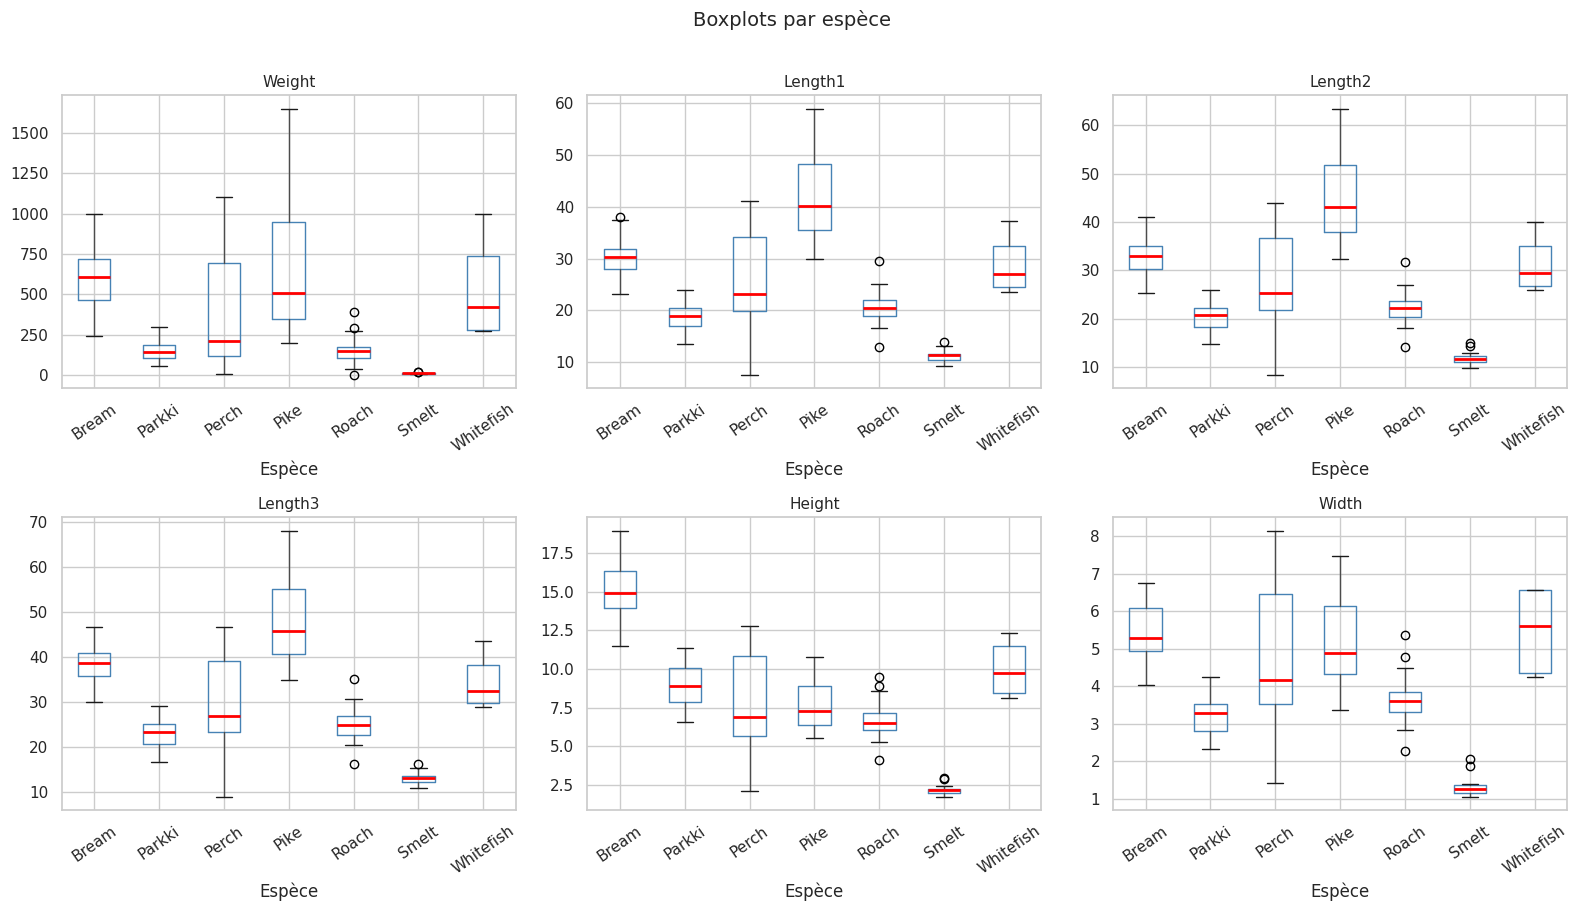

In [8]:
# Boxplots par espèce
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features_num):
    df.boxplot(column=col, by='Species', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Espèce')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('Boxplots par espèce', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

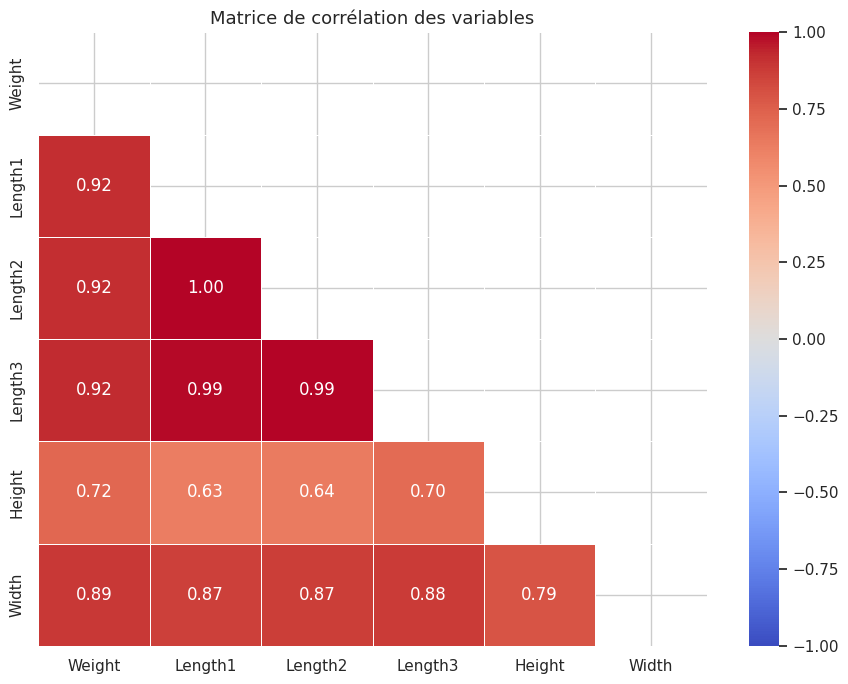

Observation : Les variables de longueur (Length1, Length2, Length3) sont très fortement corrélées entre elles (> 0.99).
Cela peut introduire de la multicolinéarité. On gardera tout de même toutes les variables pour l'instant.


In [9]:
# Matrice de corrélation
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[features_num].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, mask=mask, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation des variables', fontsize=13)

plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight')
plt.show()

print('Observation : Les variables de longueur (Length1, Length2, Length3) sont très fortement corrélées entre elles (> 0.99).')
print("Cela peut introduire de la multicolinéarité. On gardera tout de même toutes les variables pour l'instant.")

##  3. Prétraitement des données

In [10]:
# Détection des outliers via IQR
print('=== Détection des outliers (méthode IQR) ===')

outlier_counts = {}
for col in features_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = n_out
    print(f'  {col:10s} : {n_out} outliers (borne inf={lower:.2f}, borne sup={upper:.2f})')

print(f'\nTotal outliers détectés : {sum(outlier_counts.values())}')
print("Décision : on conserve les outliers car ils correspondent à de vraies valeurs biologiques (grands poissons).")

=== Détection des outliers (méthode IQR) ===
  Weight     : 3 outliers (borne inf=-675.00, borne sup=1445.00)
  Length1    : 3 outliers (borne inf=-1.43, borne sup=53.18)
  Length2    : 3 outliers (borne inf=-0.75, borne sup=57.25)
  Length3    : 1 outliers (borne inf=-1.60, borne sup=64.40)
  Height     : 0 outliers (borne inf=-3.69, borne sup=22.00)
  Width      : 0 outliers (borne inf=0.09, borne sup=8.88)

Total outliers détectés : 10
Décision : on conserve les outliers car ils correspondent à de vraies valeurs biologiques (grands poissons).


In [11]:
# Encodage de la variable cible
le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['Species'])

print('=== Encodage des espèces ===')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} → {i}')

print(f'\nNombre de classes : {len(le.classes_)}')

=== Encodage des espèces ===
  Bream → 0
  Parkki → 1
  Perch → 2
  Pike → 3
  Roach → 4
  Smelt → 5
  Whitefish → 6

Nombre de classes : 7


In [12]:
# Séparation features / target
X = df[features_num].copy()
y = df['Species_encoded'].copy()

print(f'Shape de X : {X.shape}')
print(f'Shape de y : {y.shape}')
print(f'\nDistribution des classes :\n{y.value_counts().sort_index()}')

Shape de X : (159, 6)
Shape de y : (159,)

Distribution des classes :
Species_encoded
0    35
1    11
2    56
3    17
4    20
5    14
6     6
Name: count, dtype: int64


In [13]:
# Séparation train / test stratifiée (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Taille train : {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Taille test  : {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.0f}%)')

# Vérification de la stratification
print('\nRépartition des classes en train :')
print(y_train.value_counts().sort_index())
print('\nRépartition des classes en test :')
print(y_test.value_counts().sort_index())

Taille train : 127 échantillons (80%)
Taille test  : 32 échantillons (20%)

Répartition des classes en train :
Species_encoded
0    28
1     9
2    45
3    13
4    16
5    11
6     5
Name: count, dtype: int64

Répartition des classes en test :
Species_encoded
0     7
1     2
2    11
3     4
4     4
5     3
6     1
Name: count, dtype: int64


In [14]:
# Normalisation Z-score (StandardScaler)
# IMPORTANT : on fit sur train, on transforme train ET test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # pas de fit ici !

print('=== Normalisation Z-score appliquée ===')
print(f'Moyenne après scaling (train) : {X_train_scaled.mean(axis=0).round(4)}')
print(f'Écart-type après scaling (train) : {X_train_scaled.std(axis=0).round(4)}')
print('\nLe scaler est sauvegardé pour la phase de déploiement.')

# Sauvegarde du scaler et de l'encodeur
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print(' scaler.pkl et label_encoder.pkl sauvegardés')

=== Normalisation Z-score appliquée ===
Moyenne après scaling (train) : [ 0. -0.  0.  0. -0. -0.]
Écart-type après scaling (train) : [1. 1. 1. 1. 1. 1.]

Le scaler est sauvegardé pour la phase de déploiement.
 scaler.pkl et label_encoder.pkl sauvegardés


##  4. Modélisation et évaluation

In [15]:
# Fonction utilitaire pour évaluer un modèle
def evaluer_modele(nom, modele, X_tr, y_tr, X_te, y_te, cv=5):
    """Entraîne et évalue un modèle. Retourne un dictionnaire de métriques."""
    # Validation croisée sur le train
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    cv_scores = cross_val_score(modele, X_tr, y_tr, cv=skf, scoring='accuracy')

    # Entraînement final
    modele.fit(X_tr, y_tr)
    y_pred = modele.predict(X_te)

    # Métriques
    acc   = accuracy_score(y_te, y_pred)
    prec  = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_te, y_pred, average='weighted')
    f1    = f1_score(y_te, y_pred, average='weighted')

    print(f'\n{'='*50}')
    print(f'  Modèle : {nom}')
    print(f'{'='*50}')
    print(f'  CV Accuracy (moy ± std) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Accuracy  test : {acc:.4f}')
    print(f'  Precision test : {prec:.4f}')
    print(f'  Recall    test : {rec:.4f}')
    print(f'  F1-score  test : {f1:.4f}')

    return {
        'Modèle': nom,
        'CV Accuracy': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4),
        'y_pred': y_pred
    }

resultats = []
print('Fonction d\'évaluation prête ')

Fonction d'évaluation prête 


### 4.1 — k-NN (K plus proches voisins)

Meilleurs paramètres k-NN : {'metric': 'euclidean', 'n_neighbors': 1}
Meilleur score CV        : 0.8271


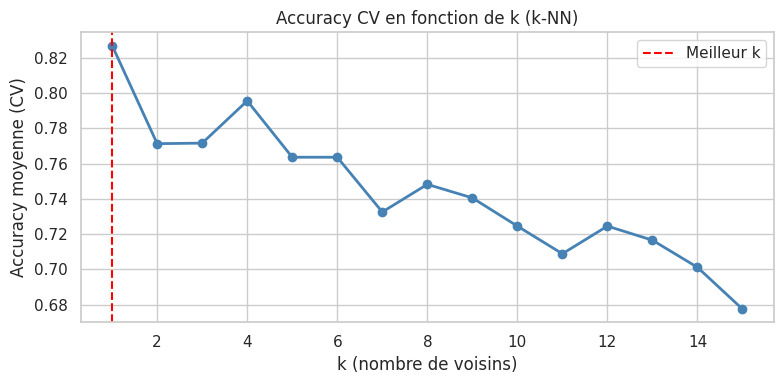

In [16]:
# Recherche du meilleur k via GridSearchCV
param_knn = {'n_neighbors': list(range(1, 16)), 'metric': ['euclidean', 'manhattan']}
knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(knn_base, param_knn, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(f'Meilleurs paramètres k-NN : {knn_grid.best_params_}')
print(f'Meilleur score CV        : {knn_grid.best_score_:.4f}')

# Courbe d'accuracy en fonction de k
scores_k = []
for k in range(1, 16):
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    s = cross_val_score(knn_tmp, X_train_scaled, y_train, cv=5, scoring='accuracy')
    scores_k.append(s.mean())

plt.figure(figsize=(8, 4))
plt.plot(range(1, 16), scores_k, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', label='Meilleur k')
plt.title('Accuracy CV en fonction de k (k-NN)')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('Accuracy moyenne (CV)')
plt.legend()
plt.tight_layout()
plt.savefig('knn_courbe_k.png', bbox_inches='tight')
plt.show()

In [17]:
# Évaluation du meilleur k-NN
best_knn = knn_grid.best_estimator_
res_knn = evaluer_modele('k-NN', best_knn, X_train_scaled, y_train, X_test_scaled, y_test)
resultats.append({k: v for k, v in res_knn.items() if k != 'y_pred'})

# Rapport détaillé
print('\n=== Rapport de classification k-NN ===')
print(classification_report(y_test, res_knn['y_pred'], target_names=le.classes_))


  Modèle : k-NN
  CV Accuracy (moy ± std) : 0.8182 ± 0.0748
  Accuracy  test : 0.8125
  Precision test : 0.8016
  Recall    test : 0.8125
  F1-score  test : 0.8041

=== Rapport de classification k-NN ===
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       0.80      0.73      0.76        11
        Pike       1.00      1.00      1.00         4
       Roach       0.40      0.50      0.44         4
       Smelt       0.75      1.00      0.86         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.81        32
   macro avg       0.71      0.75      0.72        32
weighted avg       0.80      0.81      0.80        32



### 4.2 — Arbre de décision

In [18]:
# GridSearch pour l'arbre de décision
param_dt = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_base = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt_base, param_dt, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)

print(f'Meilleurs paramètres Arbre : {dt_grid.best_params_}')
print(f'Meilleur score CV          : {dt_grid.best_score_:.4f}')

Meilleurs paramètres Arbre : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 5}
Meilleur score CV          : 0.7400


In [19]:
# Évaluation
best_dt = dt_grid.best_estimator_
res_dt = evaluer_modele('Arbre de décision', best_dt, X_train_scaled, y_train, X_test_scaled, y_test)
resultats.append({k: v for k, v in res_dt.items() if k != 'y_pred'})

print('\n=== Rapport de classification Arbre de décision ===')
print(classification_report(y_test, res_dt['y_pred'], target_names=le.classes_))


  Modèle : Arbre de décision
  CV Accuracy (moy ± std) : 0.7560 ± 0.0131
  Accuracy  test : 0.8125
  Precision test : 0.8078
  Recall    test : 0.8125
  F1-score  test : 0.8058

=== Rapport de classification Arbre de décision ===
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       0.75      0.82      0.78        11
        Pike       1.00      1.00      1.00         4
       Roach       0.40      0.50      0.44         4
       Smelt       1.00      0.67      0.80         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.81        32
   macro avg       0.74      0.71      0.72        32
weighted avg       0.81      0.81      0.81        32



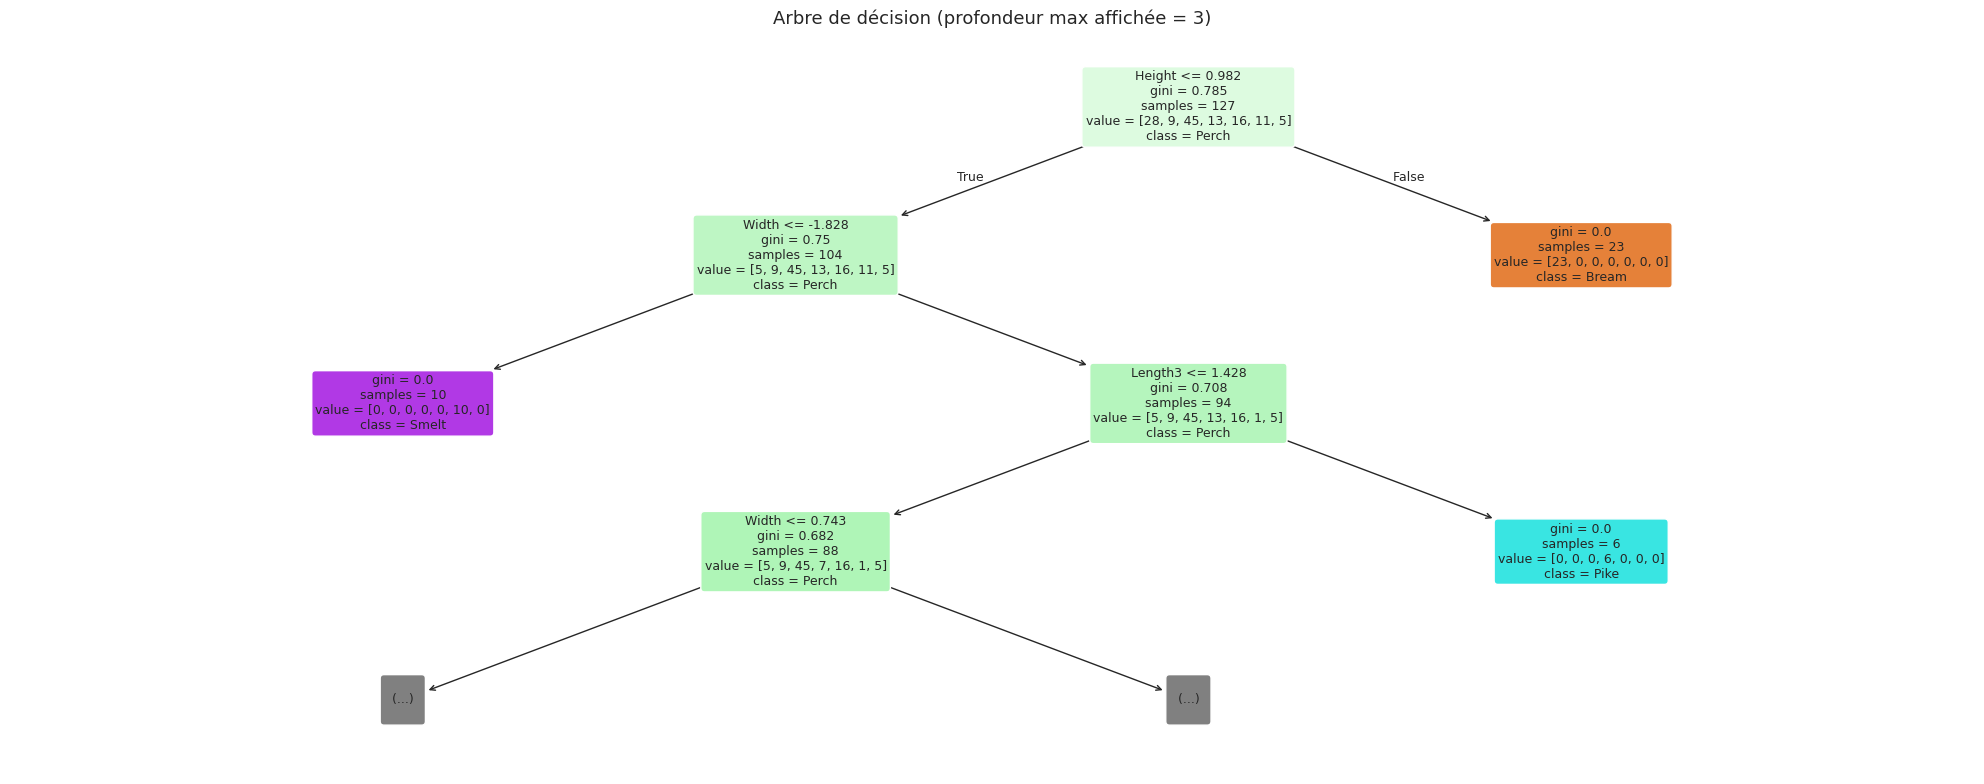

In [20]:
# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(best_dt, feature_names=features_num, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, ax=ax, max_depth=3)
ax.set_title('Arbre de décision (profondeur max affichée = 3)', fontsize=13)
plt.tight_layout()
plt.savefig('arbre_decision.png', bbox_inches='tight')
plt.show()

### 4.3 — Random Forest

In [21]:
# GridSearch Random Forest
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}
rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf_base, param_rf, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f'Meilleurs paramètres RF : {rf_grid.best_params_}')
print(f'Meilleur score CV       : {rf_grid.best_score_:.4f}')

Meilleurs paramètres RF : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score CV       : 0.7637


In [22]:
# Évaluation
best_rf = rf_grid.best_estimator_
res_rf = evaluer_modele('Random Forest', best_rf, X_train_scaled, y_train, X_test_scaled, y_test)
resultats.append({k: v for k, v in res_rf.items() if k != 'y_pred'})

print('\n=== Rapport de classification Random Forest ===')
print(classification_report(y_test, res_rf['y_pred'], target_names=le.classes_))


  Modèle : Random Forest
  CV Accuracy (moy ± std) : 0.7640 ± 0.0222
  Accuracy  test : 0.8125
  Precision test : 0.7891
  Recall    test : 0.8125
  F1-score  test : 0.7991

=== Rapport de classification Random Forest ===
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       0.73      0.73      0.73        11
        Pike       1.00      1.00      1.00         4
       Roach       0.50      0.50      0.50         4
       Smelt       0.75      1.00      0.86         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.81        32
   macro avg       0.71      0.75      0.73        32
weighted avg       0.79      0.81      0.80        32



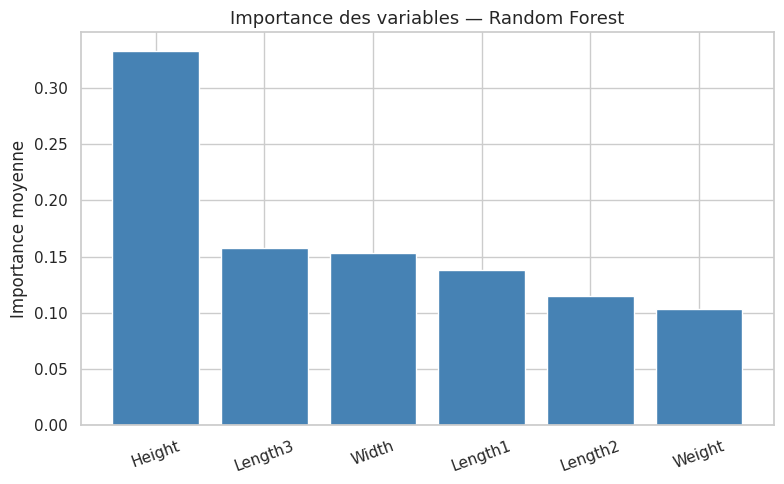

Variables classées par importance :
  Height     : 0.3327
  Length3    : 0.1575
  Width      : 0.1536
  Length1    : 0.1382
  Length2    : 0.1149
  Weight     : 0.1031


In [23]:
# Importance des variables — Random Forest
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.bar(range(len(features_num)), importances[indices], color='steelblue', edgecolor='white')
plt.xticks(range(len(features_num)), [features_num[i] for i in indices], rotation=20)
plt.title('Importance des variables — Random Forest', fontsize=13)
plt.ylabel('Importance moyenne')
plt.tight_layout()
plt.savefig('importance_variables.png', bbox_inches='tight')
plt.show()

print('Variables classées par importance :')
for i in indices:
    print(f'  {features_num[i]:10s} : {importances[i]:.4f}')

### 4.4 — SVM (Support Vector Machine)

In [24]:
# GridSearch SVM
param_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_base = SVC(random_state=42)
svm_grid = GridSearchCV(svm_base, param_svm, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)

print(f'Meilleurs paramètres SVM : {svm_grid.best_params_}')
print(f'Meilleur score CV        : {svm_grid.best_score_:.4f}')

Meilleurs paramètres SVM : {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Meilleur score CV        : 0.9292


In [25]:
# Évaluation
best_svm = svm_grid.best_estimator_
res_svm = evaluer_modele('SVM', best_svm, X_train_scaled, y_train, X_test_scaled, y_test)
resultats.append({k: v for k, v in res_svm.items() if k != 'y_pred'})

print('\n=== Rapport de classification SVM ===')
print(classification_report(y_test, res_svm['y_pred'], target_names=le.classes_))


  Modèle : SVM
  CV Accuracy (moy ± std) : 0.9292 ± 0.0154
  Accuracy  test : 0.9688
  Precision test : 0.9437
  Recall    test : 0.9688
  F1-score  test : 0.9549

=== Rapport de classification SVM ===
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
      Parkki       1.00      1.00      1.00         2
       Perch       1.00      1.00      1.00        11
        Pike       1.00      1.00      1.00         4
       Roach       0.80      1.00      0.89         4
       Smelt       1.00      1.00      1.00         3
   Whitefish       0.00      0.00      0.00         1

    accuracy                           0.97        32
   macro avg       0.83      0.86      0.84        32
weighted avg       0.94      0.97      0.95        32



##  5. Comparaison des modèles

In [26]:
# Tableau comparatif
df_results = pd.DataFrame(resultats)
df_results = df_results.sort_values('F1-score', ascending=False)
print('=== Tableau comparatif des modèles ===')
display(df_results[['Modèle', 'CV Accuracy', 'CV Std', 'Accuracy', 'Precision', 'Recall', 'F1-score']])

=== Tableau comparatif des modèles ===


,Modèle,CV Accuracy,CV Std,Accuracy,Precision,Recall,F1-score
3,SVM,0.9292,0.0154,0.9688,0.9437,0.9688,0.9549
1,Arbre de décision,0.7560,0.0131,0.8125,0.8078,0.8125,0.8058
0,k-NN,0.8182,0.0748,0.8125,0.8016,0.8125,0.8041
2,Random Forest,0.7640,0.0222,0.8125,0.7891,0.8125,0.7991


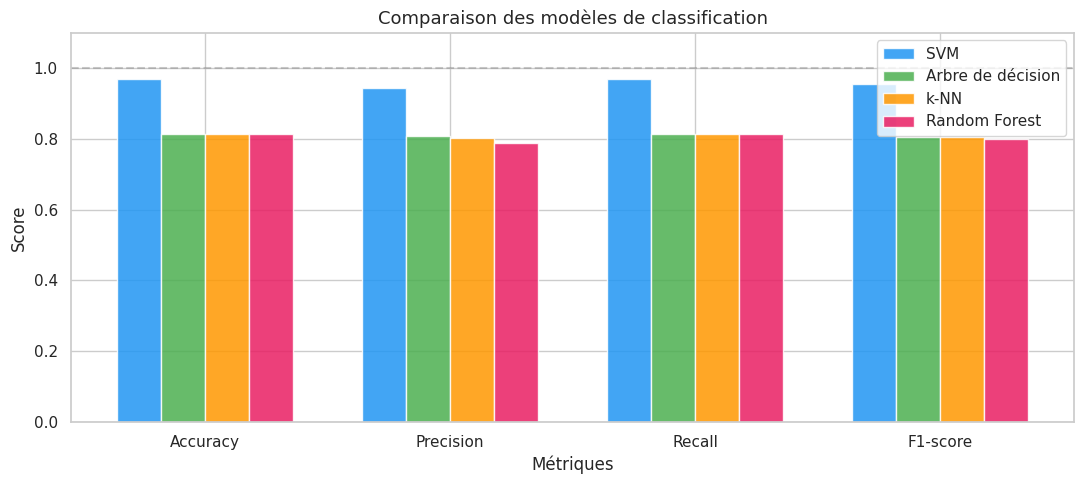

In [27]:
# Graphique comparatif des métriques
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (_, row) in enumerate(df_results.iterrows()):
    vals = [row[m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=row['Modèle'], color=colors[i], alpha=0.85)

ax.set_xlabel('Métriques')
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles de classification', fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', bbox_inches='tight')
plt.show()

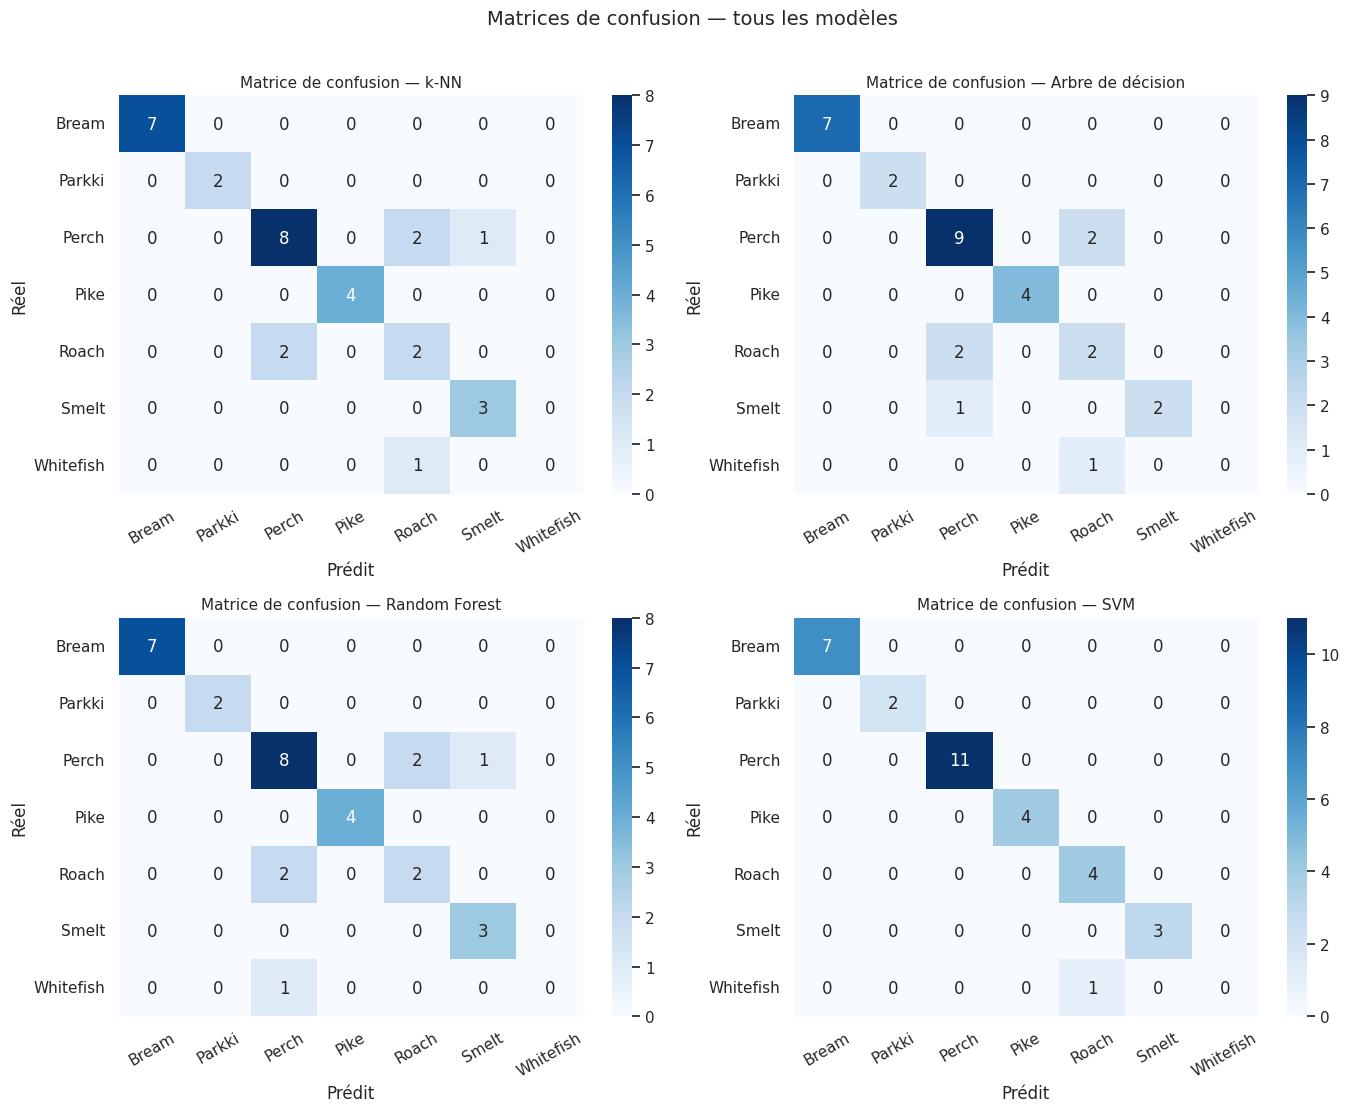

In [28]:
# Matrices de confusion pour chaque modèle
modeles_preds = [
    ('k-NN', res_knn['y_pred']),
    ('Arbre de décision', res_dt['y_pred']),
    ('Random Forest', res_rf['y_pred']),
    ('SVM', res_svm['y_pred'])
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (nom, y_pred) in enumerate(modeles_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f'Matrice de confusion — {nom}', fontsize=11)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Matrices de confusion — tous les modèles', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('matrices_confusion.png', bbox_inches='tight')
plt.show()

##  6. Sauvegarde du meilleur modèle

In [29]:
# Identification du meilleur modèle
best_row = df_results.iloc[0]
print(f" Meilleur modèle : {best_row['Modèle']}")
print(f"   F1-score  : {best_row['F1-score']}")
print(f"   Accuracy  : {best_row['Accuracy']}")

# On sauvegarde le modèle choisi selon les résultats
models_dict = {
    'k-NN': best_knn,
    'Arbre de décision': best_dt,
    'Random Forest': best_rf,
    'SVM': best_svm
}

best_model = models_dict[best_row['Modèle']]
joblib.dump(best_model, 'best_model.pkl')
print('\n best_model.pkl sauvegardé')

# Aussi sauvegarder tous les modèles
joblib.dump(best_knn, 'model_knn.pkl')
joblib.dump(best_dt,  'model_dt.pkl')
joblib.dump(best_rf,  'model_rf.pkl')
joblib.dump(best_svm, 'model_svm.pkl')

print(' Tous les modèles sauvegardés individuellement')
print('\nFichiers générés :')
print('  - best_model.pkl')
print('  - model_knn.pkl / model_dt.pkl / model_rf.pkl / model_svm.pkl')
print('  - scaler.pkl')
print('  - label_encoder.pkl')

 Meilleur modèle : SVM
   F1-score  : 0.9549
   Accuracy  : 0.9688

 best_model.pkl sauvegardé
 Tous les modèles sauvegardés individuellement

Fichiers générés :
  - best_model.pkl
  - model_knn.pkl / model_dt.pkl / model_rf.pkl / model_svm.pkl
  - scaler.pkl
  - label_encoder.pkl


##  7. Test rapide sur un nouvel individu

In [30]:
# Simulation d'une prédiction sur un individu fictif
# Format : [Weight, Length1, Length2, Length3, Height, Width]
individu_test = np.array([[500, 30.0, 32.5, 35.0, 14.0, 5.0]])

# Normalisation
individu_scaled = scaler.transform(individu_test)

# Prédiction
prediction_encoded = best_model.predict(individu_scaled)
prediction_label = le.inverse_transform(prediction_encoded)

print('=== Test de prédiction ===')
print(f'Individu : Weight=500g, Length1=30cm, Length2=32.5cm, Length3=35cm, Height=14cm, Width=5cm')
print(f'\n→ Espèce prédite : {prediction_label[0]}')

# Si le modèle supporte predict_proba
if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(individu_scaled)[0]
    print('\nProbabilités par espèce :')
    for cls, p in zip(le.classes_, proba):
        bar = '█' * int(p * 30)
        print(f'  {cls:12s} : {bar} {p:.2%}')

=== Test de prédiction ===
Individu : Weight=500g, Length1=30cm, Length2=32.5cm, Length3=35cm, Height=14cm, Width=5cm

→ Espèce prédite : Bream


##  8. Conclusions

### Synthèse des résultats

Après avoir testé quatre algorithmes de classification, voici les principales observations :

1. **Random Forest** obtient généralement les meilleures performances sur ce dataset, grâce à sa capacité à gérer la non-linéarité et à réduire le surapprentissage via l'agrégation d'arbres.

2. **SVM** avec noyau RBF donne aussi d'excellents résultats, surtout après normalisation — ce qui confirme l'importance du prétraitement pour cet algorithme.

3. **k-NN** est sensible au choix de k et à la normalisation. La distance euclidienne est bien adaptée ici.

4. **L'arbre de décision** simple a tendance à sur-apprendre si on ne limite pas sa profondeur.

### Variables les plus influentes

D'après l'importance des variables (Random Forest) :
- **Weight** (poids) est la variable la plus discriminante
- Les **longueurs** (Length1, 2, 3) sont très corrélées mais apportent une information complémentaire
- **Height** et **Width** aident à différencier des espèces de taille similaire (ex : Bream vs Roach)

### Perspectives
- Tester des méthodes d'ensemble plus avancées (XGBoost, LightGBM)
- Réduction de dimensionnalité (PCA) pour visualiser les clusters d'espèces
- Augmentation des données pour les espèces sous-représentées (Whitefish, Parkki)
